Embeddings are basically the way to trasnlate words into a langauge that cmputers understand like numbers

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

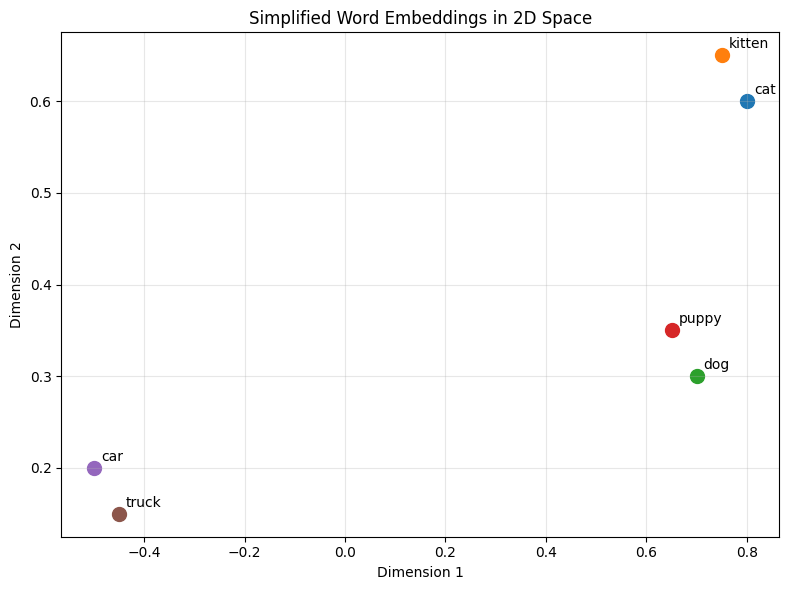

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
#  Cosine similarity

In [6]:
def cosine_similarity(vec1,vec2):
    """
    Cosine similarity is defined as the cosine of the angle between two vectors
    1.Result similary to1:very similar
    2.Result similary to0:not similar
    3.Result similary to-1:completely opposite
    """
    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a*norm_b)
    

In [7]:
#example\
cat_score=[0.8,0.9,0.75]
car_score=[0.75,0.85,0.70]

In [8]:
cosine_similarity(cat_score,car_score)

np.float64(0.9999877525275718)

In [9]:
#Embeddings

In [10]:
#embeddings with huggingface and OPENAI MODELs
from langchain_huggingface import HuggingFaceEmbeddings

#initialize z simple embddings model
embeddings=HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',

)
embeddings


c:\Users\PARAS\Downloads\krish-naik-new-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [11]:
text="Hello i am learning about embeddings"
embeddings.embed_query(text)
# List of dirreent texts so we use emdbssings model
print(f"Text{text}")
print (f"Embeddings length {len(embeddings.embed_query(text))}")
embeddings

TextHello i am learning about embeddings
Embeddings length 384


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [12]:
sentences=[
    'Build powerful RAG pipeline: Traditional, Advanced, Multimodal & Agentic AI with LangChain,LangGraph and Langsmith'
]
embeddings_sentences=embeddings.embed_documents(sentences)

print(embeddings_sentences)

[[-0.08464931696653366, -0.002270172815769911, 0.07250364124774933, -0.05894310027360916, -0.08683668076992035, -0.017658725380897522, -0.019713012501597404, -0.023511450737714767, -0.03249230608344078, -0.010289099998772144, -0.04873079061508179, -0.07225139439105988, 0.009816103614866734, 0.011280220001935959, -0.019927162677049637, 0.11711268126964569, 0.022447500377893448, 0.1798076182603836, -0.051482345908880234, -0.08030983060598373, 0.010286910459399223, 0.015831749886274338, 0.028440214693546295, -0.07961362600326538, 0.013459622859954834, 0.026049282401800156, -0.009925280697643757, -0.07154588401317596, 0.07603418827056885, -0.05222271755337715, 0.044659875333309174, 0.02434626594185829, -0.01939389854669571, -0.020290810614824295, -0.05927756801247597, 0.10178285092115402, -0.08519181609153748, 0.018669145181775093, 0.05880923941731453, -0.0042547062039375305, 0.011253347620368004, 0.038171444088220596, -0.002266631228849292, -0.12092011421918869, 0.07561939209699631, 0.012

In [13]:
#calcualting the cosine silimarity
from sklearn.metrics.pairwise import cosine_similarity

# assume embeddings_sentences is a list of numpy arrays
for i in range(len(embeddings_sentences)):
    for j in range(i+1, len(embeddings_sentences)):
        # reshape to 2D
        sim = cosine_similarity(
            embeddings_sentences[i].reshape(1, -1),
            embeddings_sentences[j].reshape(1, -1)
        )
        print(f"Sentence {i} vs {j} -> Similarity: {sim[0][0]}")
        

In [14]:
print("Number of sentences:", len(sentences))

Number of sentences: 1


In [15]:
# Install if needed
# pip install transformers sentence-transformers scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# Load model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
sentences = [
    "I love programming in Python.",
    "Python is great for machine learning.",
    "The sky is clear and blue today."
]

# Generate embeddings
embeddings = model.encode(sentences)

In [16]:
# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Print results
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        print(f"Sentence {i} vs {j}")
        print(f"  '{sentences[i]}'")
        print(f"  '{sentences[j]}'")
        print(f"  Similarity: {similarity_matrix[i][j]:.4f}\n")

Sentence 0 vs 1
  'I love programming in Python.'
  'Python is great for machine learning.'
  Similarity: 0.7118

Sentence 0 vs 2
  'I love programming in Python.'
  'The sky is clear and blue today.'
  Similarity: -0.0010

Sentence 1 vs 2
  'Python is great for machine learning.'
  'The sky is clear and blue today.'
  Similarity: -0.0048



In [17]:
sentences = [
    "How can reinforcement learning be applied to optimize energy consumption in smart cities while balancing sustainability and economic growth?",
    "Explain the ethical implications of using generative AI models in healthcare diagnostics, especially when patient data privacy is at risk.",
    "What are the main architectural differences between transformer-based language models and traditional recurrent neural networks, and how do these differences affect scalability?",
    "In the context of climate change, how can machine learning models help predict extreme weather events, and what challenges exist in ensuring their accuracy?",
    "Discuss the role of quantum computing in advancing cryptography, and analyze whether current encryption standards will remain secure in the next decade.",
    "How can multimodal AI systems integrate vision, language, and audio data to improve human-computer interaction in educational environments?",
    "Evaluate the potential risks and benefits of autonomous vehicles in densely populated urban areas, considering both technological limitations and societal acceptance.",
    "What strategies can organizations adopt to ensure fairness and transparency when deploying large-scale AI systems in hiring and recruitment processes?",
    "Analyze the trade-offs between centralized and decentralized approaches to training large language models, particularly in terms of efficiency, privacy, and collaboration.",
    "How can edge computing combined with federated learning enable real-time AI applications in healthcare without compromising patient confidentiality?"
]

embedding_model=model.encode(sentences)
similarity=cosine_similarity(embedding_model)

In [28]:
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        print(f"Sentence {i} vs {j}")
        print(f"  '{sentences[i]}'")
        print(f"  '{sentences[j]}'")
        print(f"  Similarity: {similarity_matrix[i][j]:.4f}\n")


Sentence 0 vs 1
  'How can reinforcement learning be applied to optimize energy consumption in smart cities while balancing sustainability and economic growth?'
  'Explain the ethical implications of using generative AI models in healthcare diagnostics, especially when patient data privacy is at risk.'
  Similarity: 0.7118

Sentence 0 vs 2
  'How can reinforcement learning be applied to optimize energy consumption in smart cities while balancing sustainability and economic growth?'
  'What are the main architectural differences between transformer-based language models and traditional recurrent neural networks, and how do these differences affect scalability?'
  Similarity: -0.0010

Sentence 0 vs 3
  'How can reinforcement learning be applied to optimize energy consumption in smart cities while balancing sustainability and economic growth?'
  'In the context of climate change, how can machine learning models help predict extreme weather events, and what challenges exist in ensuring the

IndexError: index 3 is out of bounds for axis 0 with size 3

In [29]:
documents = [
    "How can reinforcement learning be applied to optimize energy consumption in smart cities while balancing sustainability and economic growth?",
    "Explain the ethical implications of using generative AI models in healthcare diagnostics, especially when patient data privacy is at risk.",
    "What are the main architectural differences between transformer-based language models and traditional recurrent neural networks, and how do these differences affect scalability?",
    "In the context of climate change, how can machine learning models help predict extreme weather events, and what challenges exist in ensuring their accuracy?",
    "Discuss the role of quantum computing in advancing cryptography, and analyze whether current encryption standards will remain secure in the next decade.",
    "How can multimodal AI systems integrate vision, language, and audio data to improve human-computer interaction in educational environments?",
    "Evaluate the potential risks and benefits of autonomous vehicles in densely populated urban areas, considering both technological limitations and societal acceptance.",
    "What strategies can organizations adopt to ensure fairness and transparency when deploying large-scale AI systems in hiring and recruitment processes?",
    "Analyze the trade-offs between centralized and decentralized approaches to training large language models, particularly in terms of efficiency, privacy, and collaboration.",
    "How can edge computing combined with federated learning enable real-time AI applications in healthcare without compromising patient confidentiality?"
]
query="What is multimodal AI?"

In [41]:
#analyzing context, word relationships, and user intent using AI,
def sematic_search(query,documents,embedding_model,top_k=3):
    """Simple semantic search implementation"""
    query_embed=embedding_model.embed_query(query)
    doc_embed=embedding_model.embed_query(documents)

    simillarities=[]
    for i,doc_emb in enumerate(doc_embed):
        similarity=cosine_similarity(query_embed,doc_embed)
        simillarities.append(similarity,documents[i])

    #sort by similarity
    simillarities.sort(reverse=True)
    return simillarities[:top_k]

In [42]:
results=sematic_search(query,documents,embeddings_sentences)

AttributeError: 'list' object has no attribute 'embed_query'

In [40]:
query="what is embeddings?"
results=sematic_search(query,documents,embeddings)
results

AttributeError: 'list' object has no attribute 'replace'